# Олег и Никита. Материалы по Docker

Дедлайн материалов семинара: 23-24 мая; **25 мая - край**

Дедлайн материалов дз: **3 июня**

Общий план:

1. Через что проводить семинар? **проводим через Colab или аналогичное окружение, которое собрано за нас в online**
2. Через что даем дз? **так же как и семинар**


1 семинар:
* еще раз напоминание по лекции + разбор вопросов
* изучение всех основных базовых команд
* окружения, примеры с pip install, что это вообще означает
* все то, что нужно будет дать перед вторым семинаром
...
* продумать активность


2 семинар: на примере какого-то приложения
* заканчиваем то, что не успели на первом семинаре
* через проблематику, попробуем показать, что че то не работает и надо это делать через докер либо просто на словах
* через поставленную проблематику постепенно разворачиваем приложение

ДЗ:
* понять что примерно даем (ответвление от семинара или полностью что-то новое????)

* наполненность в рамках проекта, то есть каждый что-то свое добавляет (тг бот, можно что-то еще, достаточно легко реализуемое через python)





# Superplan

In [ ]:
Есть очень классная штука
https://github.com/features/codespaces это буквально через github открывается online vs code,
где предустановлен docker практически со всеми его возможностями, включая compose

ВАЖНО: есть квота на использование в 60 часов, если зарегаться по студенческому пакету, то будет 180 часов https://education.github.com/pack
надо обязательно попробовать тебе зарегаться, так как я не студент, мне не одобрят


In [ ]:
можно попробовать уже построить простой образ и по нему запустить контейнер:

docker build -t simple_image .
docker run simple_image:latest

# Docker с курса маги

Docker – это платформа, которая позволяет «создавать, поставлять и запускать любое приложение повсюду».

## Установка Docker

Docker доступен для любой из операционных систем: Windows, Linux, Max. Для скачивания установочного файла - перейдите по [ссылке](https://docs.docker.com/get-started/get-docker/) и выберите подходящую вам версию.

Docker предоставляет 2 сборки:
* Community Edition (полностью бесплатная версия)
* Enterprise Edition

## Проверка что все установилось

In [ ]:
!docker

/bin/bash: line 1: docker: command not found


In [ ]:
!docker-compose

In [ ]:
!sudo docker run hello-world

## Основные понятия

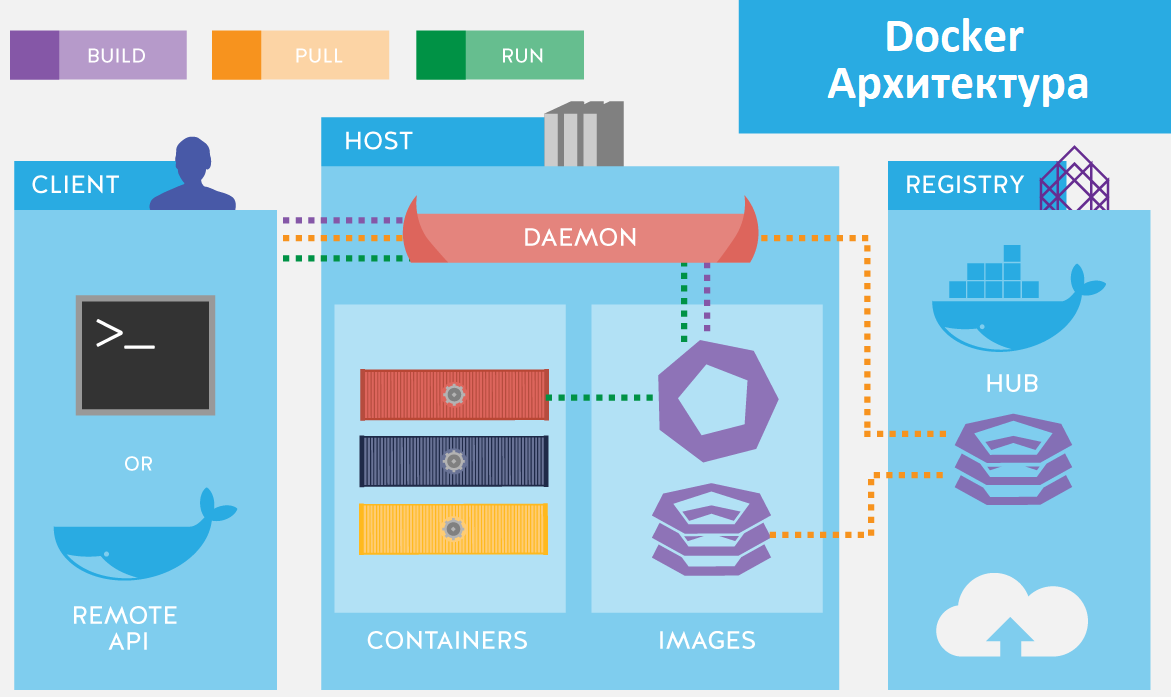



*   **Docker host** — это операционная система, на которую устанавливают Docker и на которой он работает
*   **Docker daemon** — служба, которая управляет Docker-объектами: сетями, хранилищами, образами и контейнерами
*   **Docker client** — консольный клиент, при помощи которого пользователи взаимодействуют с Docker daemon и отправляют ему команды, создают контейнеры и управляют ими
*   **Docker image** — это неизменяемый образ, из которого разворачивается контейнер
*   **Docker container** — развёрнутое и запущенное приложение
*   **Docker Registry** — репозиторий, в котором хранятся образы
*   **Dockerfile** — файл-инструкция для сборки образа
*   **Docker Compose** — инструмент для управления несколькими контейнерами. Он позволяет создавать контейнеры и задавать их конфигурацию
*   **Docker Desktop** — GUI-клиент, который распространяется по GPL. Бесплатная версия работает на Windows, macOS, а с недавних пор и на Linux. Это очень удобный клиент, который отображает все сущности Docker и позволяет запустить однонодовый Kubernetes для компьютера


## Жизненный цикл контейнера

* Создание контейнера
* Работа контейнера
* Приостановка контейнера
* Возобновление работы контейнера
* Запуск контейнера
* Остановка контейнера
* Перезапуск контейнера
* Принудительная остановка контейнера
* Удаление контейнера

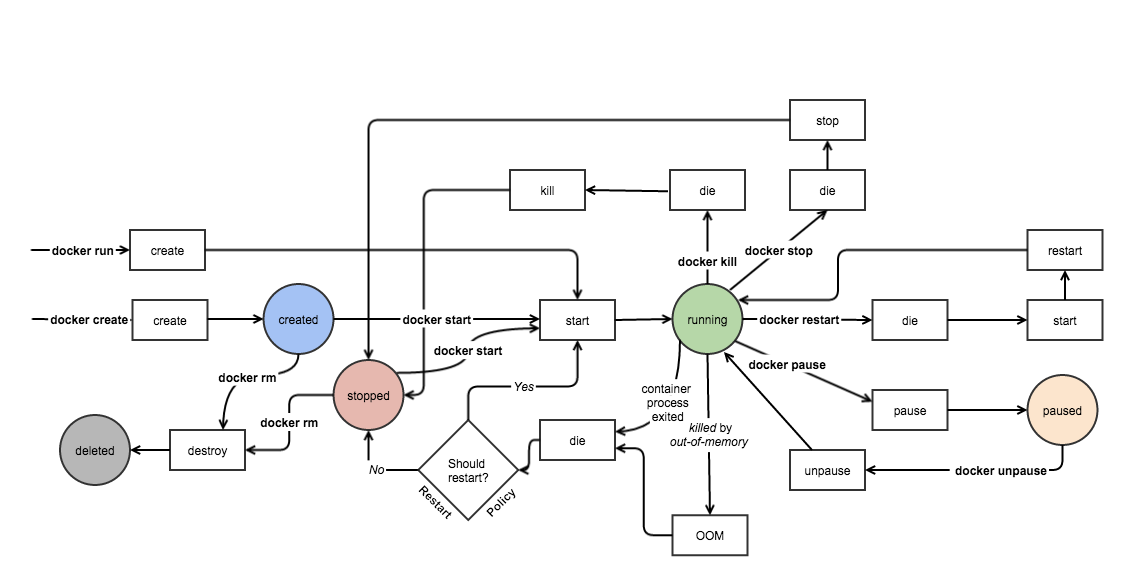

## Docker Hub

* https://hub.docker.com/_/python
* https://hub.docker.com/_/postgres
* https://hub.docker.com/_/node

## Основные команды Docker

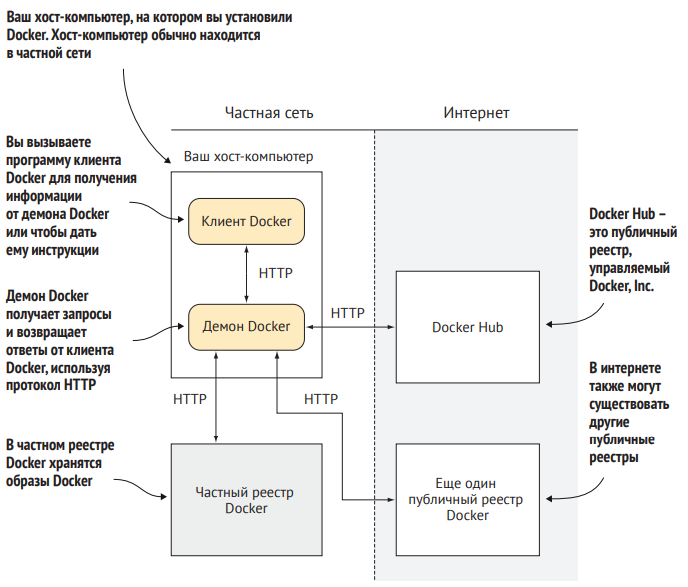

### Запуска контейнера из образа

С помощью этой команды вы можете указать образ, который вы хотите использовать, и определить любые дополнительные параметры, такие как монтирование томов или проброс портов.

* [Документация](https://docs.docker.com/reference/cli/docker/container/run/)

`$ docker run [OPTIONS] IMAGE [COMMAND] [ARG...]`

### Список доступных образов Docker на хост-системе

`$ docker images [OPTIONS] [REPOSITORY[:TAG]]`

### Список работающих контейнеров Docker

`$ docker ps [OPTIONS]`

## Docker Image и Docker Container

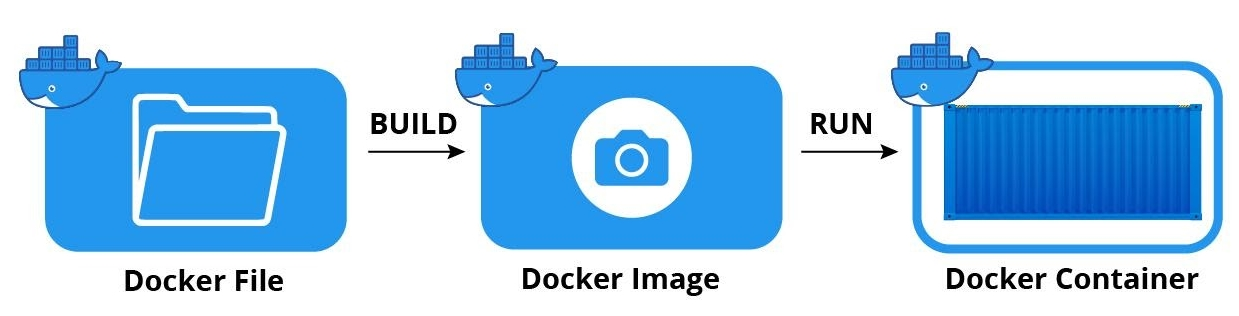

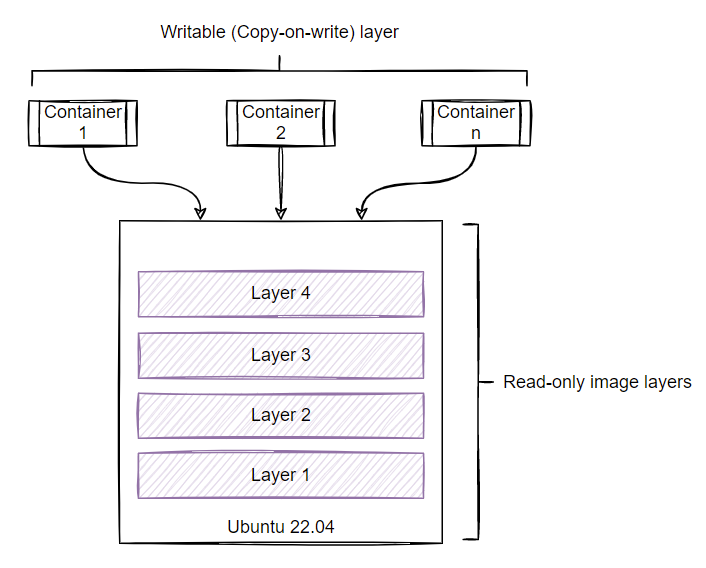

## Dockerfile

Dockerfile — это сценарий, который содержит набор команд и инструкций для создания Docker-образа. Docker-образ, в свою очередь, является неизменяемым шаблоном, который включает в себя все необходимое для запуска контейнера: операционную систему, библиотеки, зависимости и само приложение.

### Инструкции Dockerfile

| Инструкция    | Описание                                                                                                   | Пример                                                                     |
|---------------|------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------|
| `FROM`        | Задает родительский образ. Все последующие инструкции создают слои поверх родительского образа             | `FROM nginx:latest`                                                        |
| `RUN`         | Выполняет команду внутри контейнера c сохранением результата                                               | `RUN mkdir /etc/nginx/`<br>`RUN apt-get update && apt-get install nginx -y` |
| `COPY`        | Копирует файлы и папки из текущей директории, где находится Dockerfile в указанную директорию в контейнере | `COPY . /etc/nginx/`                                                       |
| `ADD`         | Копирует файлы и папки из текущей позиции Dockerfile, скачивает файлы по URL и работает с tar-архивами     | `ADD https://mhost.by/archive/demo_config.ini /etc/nginx/`                 |
| `ENV`         | Задает переменные среды внутри образа                                                                      | `ENV ADMIN="nginx"`                                                        |
| `ARG`         | Переменные, которые передается докером во время сборки образа                                              | `ARG maintainer=nginx`                                                     |
| `WORKDIR`     | Устанавливает рабочую директорию контейнера                                                                | `WORKDIR /etc/nginx/`                                                      |
| `VOLUME`      | Создает и подключает постоянный том хранения данных                                                        | `VOLUME /data_1`                                                           |
| `EXPOSE`      | Указывает локальный порт контейнера. Инструкция сама по себе не открывает порт                             | `EXPOSE 80`                                                                |
| `LABEL`       | Добавляет метаданные в образ                                                                               | `LABEL maintainer="nginx_test"`                                            |
| `CMD`         | Выполняет команду с указанными аргументами во время запуска контейнера                                     | `CMD ["nginx","-g","daemon off;"]`                                         |
| `ENTRYPOINT`  | Похожа на CMD, но при запуске контейнера не переопределяется в отличие от CMD                              | `ENTRYPOINT ["nginx","-g","daemon off;"]`                                  |

**`Dockerfile`**
```
FROM python:3.12-alpine # Установка базового образа

WORKDIR /app # Создание рабочего каталога

COPY requirements.txt . # Копирование списка зависимостей

RUN pip install --no-cache-dir -r requirements.txt # Установка зависимостей

COPY . . # Копирование файлов приложения

CMD ["python", "app.py"] # Запуск приложения
```

### Сборка образа

Команда `docker build` используется для сборки образа из Dockerfile.  
* [Документация](https://docs.docker.com/engine/reference/commandline/build/)

`$ docker build [OPTIONS] PATH | URL | -`

### Пример

Создадим проект в IDE (PyCharm / VSCode) со следующей структурой

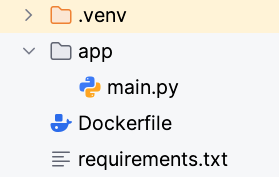

`main.py`

```Python
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
async def root():
    return {"message": "Hello World"}


@app.get("/items/{item_id}")
def read_item(item_id: int):
    return {"item_id": item_id}
```

`Dockerfile`

```
FROM python:3.13-alpine

LABEL authors="Evgeny"

WORKDIR /code

COPY ./requirements.txt /code/requirements.txt

RUN pip install -r /code/requirements.txt

COPY ./app /code/app

CMD ["fastapi", "run", "app/main.py", "--port", "80"]
```

Фиксируем зависимости  
`$ pip freeze > requirements.txt`

Собираем свой образ из Dockerfile с именем `myimage` (и тегом `latest`)  
`$ docker build -t myimage .`

Запускаем контейнер на базе своего образа и прокидываем `80` порт  
`$ docker run -d --name mycontainer -p 80:80 myimage`

Собираем образ с именем `webserver` и тегом `1.0`  
`$ docker build -t webserver:1.0 .`

Собираем образ с именем `webserver` и тегом `2.0`  
`$ docker build -t webserver:2.0 .`

Запускаем контейнер с именем `black` из образа `webserver:1.0` на порту `8080`  
`$ docker run -it --rm -d -p 8080:80 --name black webserver:1.0`

Запускаем контейнер с именем `white` из образа `webserver:2.0` на порту `8081`  
`$ docker run -it --rm -d -p 8081:80 --name white webserver:2.0`

## Полезные ссылки

Максимально доступные короткие заметки про Docker 👇

✔️ [Часть 1: основы](https://habr.com/ru/companies/ruvds/articles/438796/)  

✔️ [Часть 2: термины и концепции](https://habr.com/ru/companies/ruvds/articles/439978/)  

✔️ [Часть 3: файлы Dockerfile](https://habr.com/ru/companies/ruvds/articles/439980/)  

✔️ [Часть 4: уменьшение размеров образов и ускорение их сборки](https://habr.com/ru/companies/ruvds/articles/440658/)  

✔️ [Часть 5: команды](https://habr.com/ru/companies/ruvds/articles/440660/)  

✔️ [Часть 6: работа с данными](https://habr.com/ru/companies/ruvds/articles/441574/)

Официальные сайты и документация 👇

* [Сайт Docker](https://www.docker.com/)
* [Документация Docker](https://docs.docker.com/)
* [Docker Hub](https://hub.docker.com/)
* [Документация Gunicorn](https://docs.gunicorn.org/en/stable/)
* [Документация PostgreSQL](https://www.postgresql.org/docs/current/index.html)
* [Документация NGINX](http://nginx.org/ru/docs/)